[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Quantitative-Research-Methods/blob/main/Chapters/Advanced/advanced_04_glms_splines/advanced_04_glms_splines_lab.ipynb)

*This notebook runs on Colab as-is. The badge link above and the `GITHUB_RAW` line in the setup cell already point to this repository, so everything installs and loads automatically.*

# Advanced Module A4 — GLMs and Splines
## Lab: Poisson regression on Bikeshare, deviance and LRTs, overdispersion, penalized splines, a count GAM

**Course:** Quantitative Research Methods
**Instructor:** Prof. Dr. Christoph Weisser
**Source:** James, Witten, Hastie, Tibshirani & Taylor (2023), *An Introduction to Statistical Learning, with Applications in Python*, Springer. Companion code at [statlearning.com](https://www.statlearning.com). This advanced module unifies the book's Chapter 4 (GLMs) and Chapter 7 (splines), meeting in penalized-spline GAMs.

**Goal.** Watch the Gaussian linear model fail on hourly bike counts; fit the Poisson GLM and read its coefficients as rate ratios; test terms with deviances and LRTs; diagnose overdispersion and repair it with quasi-Poisson and negative binomial; fit penalized splines on `Wage` with GCV choosing $\lambda$; and put it all together in a penalized-spline Poisson GAM on `Bikeshare`.

## Setup

Run this cell once. The `ISLP` package can be installed with `pip install ISLP`. As an alternative, the same data sets are available as CSVs in the workspace's `ALL CSV FILES - 2nd Edition` folder.


> **Google Colab:** this notebook also runs on Colab out of the box — the setup cell below installs any missing packages and downloads the data automatically.

In [1]:
# --- Setup: runs locally AND on Google Colab --------------------------------
# Silence only the spurious 'encountered in matmul' RuntimeWarnings that the macOS
# Accelerate BLAS emits; real warnings (deprecations, model caveats) stay visible.
import warnings
warnings.filterwarnings('ignore', message='.*encountered in matmul', category=RuntimeWarning)
import importlib.util, os, subprocess, sys

IN_COLAB = 'google.colab' in sys.modules

def _ensure(pkg, import_name=None):
    """pip-install pkg (quietly) if its import is missing."""
    if importlib.util.find_spec(import_name or pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

if IN_COLAB:  # Colab ships numpy/pandas/sklearn/statsmodels; add course extras
    for _pkg, _imp in [('ISLP', 'ISLP')]:
        _ensure(_pkg, _imp)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2024)
plt.rcParams['figure.dpi'] = 110

try:
    from ISLP import load_data
    HAVE_ISLP = True
except ImportError:
    HAVE_ISLP = False
    print('ISLP not installed; using CSV / URL fallbacks.')

# Local CSV location (repo layout first, then legacy paths, then a data/ cache).
_CANDIDATES = ['../ALL CSV FILES - 2nd Edition',
               'ALL CSV FILES - 2nd Edition',
               '../../ALL CSV FILES - 2nd Edition',
               '../../../ALL CSV FILES - 2nd Edition', 'data']
CSV = next((p for p in _CANDIDATES if os.path.isdir(p)), 'data')

# GITHUB_RAW lets a fresh Colab runtime fetch any
# CSV that is neither in ISLP nor already local (spaces in the folder -> %20).
GITHUB_RAW = ('https://raw.githubusercontent.com/ChrisW09/Quantitative-Research-Methods/main/'
              'ALL%20CSV%20FILES%20-%202nd%20Edition')

# The four datasets NOT in the ISLP package -> load from the book's official
# site so the notebook works on a fresh Colab even before the repo is published.
KNOWN_URLS = {
    'Advertising': 'https://www.statlearning.com/s/Advertising.csv',
    'Heart':       'https://www.statlearning.com/s/Heart.csv',
    'Income1':     'https://www.statlearning.com/s/Income1.csv',
    'Income2':     'https://www.statlearning.com/s/Income2.csv',
}

def load(name, **read_csv_kwargs):
    """Load a course dataset. Order: ISLP package -> R datasets -> local CSV
    -> official book URL -> your GitHub repo. Works locally and on Colab."""
    if HAVE_ISLP:
        try:
            return load_data(name)
        except Exception:
            pass
    if name == 'USArrests':                       # classic R dataset, not in ISLP
        try:
            import statsmodels.api as sm
            return sm.datasets.get_rdataset('USArrests', 'datasets').data
        except Exception:
            pass
    path = f'{CSV}/{name}.csv'
    if os.path.exists(path):                      # running from the repo (local)
        return pd.read_csv(path, **read_csv_kwargs)
    remotes = ([KNOWN_URLS[name]] if name in KNOWN_URLS else []) + [f'{GITHUB_RAW}/{name}.csv']
    for url in remotes:                           # fresh Colab: stream over https
        try:
            return pd.read_csv(url, **read_csv_kwargs)
        except Exception:
            continue
    raise FileNotFoundError(
        f"Could not load {name!r}. Put the CSV in '{CSV}/' or check your connection for the GITHUB_RAW fallback.")


ISLP not installed; using CSV / URL fallbacks.


## 1. Bikeshare, and the linear model failing

`Bikeshare`: 8,645 hourly observations of bike rentals in Washington DC. Fit Chapter 3's linear model to the counts and watch it do exactly what it was told — which is the problem.

In [2]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

bike = load('Bikeshare', index_col=0)            # 8 645 hourly rows
bike['hr'] = bike['hr'].astype(int)              # hour 0..23
form = 'bikers ~ C(hr) + temp + workingday + C(weathersit)'

lm = smf.ols(form, data=bike).fit()
fv = lm.fittedvalues.values
print(f'{(fv < 0).mean():.1%} of fitted counts are negative ({(fv < 0).sum()} of {len(fv)} hours)')

# One cold, light-rain, non-working day across the 24 hours:
day = pd.DataFrame({'hr': np.arange(24), 'temp': 0.2, 'workingday': 0,
                    'weathersit': 'light rain/snow'})
print(f'linear model at 4 a.m.: {lm.predict(day)[4]:.0f} bikers')

10.0% of fitted counts are negative (861 of 8645 hours)
linear model at 4 a.m.: -105 bikers


**Reading the output.** $10.0\%$ of fitted values ($861$ hours) are *negative*, and on a cold rainy night the model predicts $-105$ riders at 4 a.m. Two distinct failures, one diagnosis: the support is wrong (a Gaussian mean can be negative, a count cannot) and the variance is wrong (quiet 4 a.m. hours vary by a few riders, busy 5 p.m. hours by hundreds). We need a model whose mean respects the data type and whose variance is tied to the mean — a **generalized linear model**.

## 2. The exponential family in one numeric check

The deck derives the Poisson as an exponential-family member with $b(\theta) = e^\theta$, so $b'(\theta) = \mu$ and $b''(\theta) = \mu$: the variance *equals* the mean. A three-line simulation confirms the mean–variance law that the whole module turns on.

In [3]:
rng = np.random.default_rng(2024)
for mu in (2.0, 10.0, 50.0):
    ysim = rng.poisson(mu, 100_000)
    print(f'Poisson(mu={mu:5.1f}):  mean {ysim.mean():7.3f}   variance {ysim.var():7.3f}')

Poisson(mu=  2.0):  mean   2.000   variance   1.993
Poisson(mu= 10.0):  mean   9.988   variance   9.925
Poisson(mu= 50.0):  mean  49.989   variance  49.894


**Reading the output.** Mean $=$ variance, at every level — the Poisson "straitjacket". Bernoulli ($V(\mu) = \mu(1-\mu)$) and Gaussian ($V(\mu) = \sigma^2$, flat) are the other two members you already know from Chapters 4 and 3; each family *fixes how spread follows the mean*, which is exactly the second thing the linear model got wrong in Section 1.

## 3. Poisson regression on Bikeshare

The GLM: $\log \mu_i = x_i^\top\beta$ with $Y_i \sim \text{Poisson}(\mu_i)$ — the canonical log link keeps every fitted mean positive, and coefficients become **log rate ratios**.

In [4]:
pois = smf.glm(form, data=bike, family=sm.families.Poisson()).fit()
print(f'deviance {pois.deviance:.1f} on {pois.df_resid} df,   log-lik {pois.llf:.1f},   AIC {pois.aic:.1f}')

terms = ['Intercept', 'temp', 'workingday',
         'C(weathersit)[T.cloudy/misty]', 'C(weathersit)[T.light rain/snow]',
         'C(weathersit)[T.heavy rain/snow]', 'C(hr)[T.8]', 'C(hr)[T.17]', 'C(hr)[T.4]']
tab = pd.DataFrame({'beta': pois.params[terms], 'SE': pois.bse[terms],
                    'rate ratio': np.exp(pois.params[terms])})
print(tab.round(3).to_string())

deviance 269005.9 on 8616 df,   log-lik -161021.8,   AIC 322101.7
                                   beta     SE  rate ratio
Intercept                         3.042  0.008      20.944
temp                              1.567  0.005       4.792
workingday                        0.002  0.002       1.002
C(weathersit)[T.cloudy/misty]    -0.051  0.002       0.951
C(weathersit)[T.light rain/snow] -0.505  0.004       0.603
C(weathersit)[T.heavy rain/snow] -1.349  0.167       0.260
C(hr)[T.8]                        1.826  0.009       6.209
C(hr)[T.17]                       1.970  0.009       7.169
C(hr)[T.4]                       -2.045  0.025       0.129


**Reading the output.** Everything lives on the log-mean scale, so exponentiate: light rain cuts the expected count to $e^{-0.505} = 0.603$ of the clear-sky rate ($39.7\%$ fewer riders, all else equal); a $+0.1$ rise in `temp` ($\approx 4^\circ$C) multiplies the rate by $e^{0.1 \times 1.567} = 1.17$; and 17:00 carries $e^{1.970 - (-2.045)} = 55.4$ times the 04:00 rate. Distrust the heavy-rain coefficient ($0.260$) — it rests on a single observed hour. Report $e^{\hat\beta}$, not $\hat\beta$.

## 4. Deviance, LRT and AIC

The deviance is the GLM's residual sum of squares; differences of deviances between nested fits are likelihood-ratio statistics. Drop `weathersit` and test it.

In [5]:
red = smf.glm('bikers ~ C(hr) + temp + workingday', data=bike,
              family=sm.families.Poisson()).fit()
LR = red.deviance - pois.deviance
q = red.df_resid - pois.df_resid
from scipy import stats
print(f'reduced deviance {red.deviance:.1f}   full {pois.deviance:.1f}')
print(f'LR = {LR:.1f} on {q} df   (chi2 95% critical value: {stats.chi2.ppf(0.95, q):.2f})')
print(f'AIC: full {pois.aic:.1f}   reduced {red.aic:.1f}')

reduced deviance 287262.7   full 269005.9
LR = 18256.8 on 3 df   (chi2 95% critical value: 7.81)
AIC: full 322101.7   reduced 340352.4


**Reading the output.** $\text{LR} = 18{,}256.8 \gg 7.81$: weather adds explanatory power far beyond chance, given hour, temperature and day type. The AICs agree ($322{,}101.7$ vs $340{,}352.4$). Two cautions from the deck: deviance differences are $\chi^2$ only for *nested* models with fixed dispersion, and AICs are only comparable across models fitted to *identical* data.

## 5. Overdispersion: quasi-Poisson and negative binomial

The Poisson family forces $\text{Var} = \mu$. Check it before believing any Poisson SE: the Pearson dispersion $\hat\varphi = X^2/(n-p)$ should be near 1.

Pearson X2 = 266229  ->  dispersion phi_hat = 30.90   (SEs must grow by sqrt(phi) = 5.56)


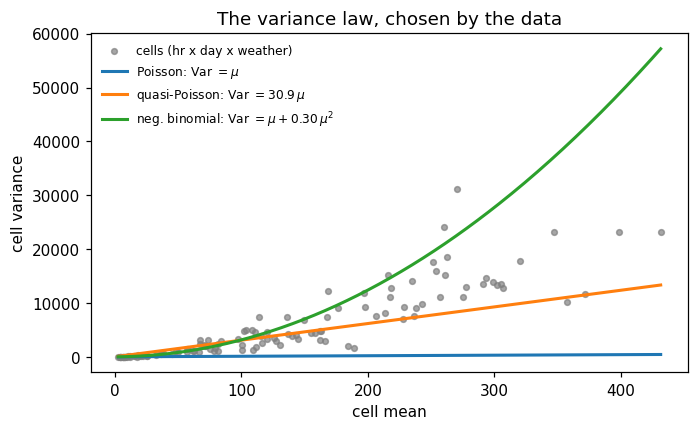

In [6]:
phi = pois.pearson_chi2 / pois.df_resid
print(f'Pearson X2 = {pois.pearson_chi2:.0f}  ->  dispersion phi_hat = {phi:.2f}'
      f'   (SEs must grow by sqrt(phi) = {np.sqrt(phi):.2f})')

# Observed cell variance vs cell mean (hr x day type x weather cells, n >= 20).
g = bike.groupby(['hr', 'workingday', 'weathersit'], observed=True)['bikers'].agg(['mean', 'var', 'count'])
g = g[g['count'] >= 20].dropna()
m = np.linspace(g['mean'].min(), g['mean'].max(), 300)
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(g['mean'], g['var'], s=14, alpha=0.7, color='grey', label='cells (hr x day x weather)')
ax.plot(m, m, color='C0', lw=2, label=r'Poisson: Var $= \mu$')
ax.plot(m, phi*m, color='C1', lw=2, label=rf'quasi-Poisson: Var $= {phi:.1f}\,\mu$')
ax.plot(m, m + 0.3049*m**2, color='C2', lw=2, label=r'neg. binomial: Var $= \mu + 0.30\,\mu^2$')
ax.set(xlabel='cell mean', ylabel='cell variance', title='The variance law, chosen by the data')
ax.legend(frameon=False, fontsize=8)
plt.show()

In [7]:
# Fix 1 -- quasi-Poisson: same estimates, honest SEs (scale='X2').
quasi = smf.glm(form, data=bike, family=sm.families.Poisson()).fit(scale='X2')

# Fix 2 -- negative binomial: estimate alpha by ML, then fit the NB GLM.
nb_ml = smf.negativebinomial(form, data=bike).fit(disp=0, maxiter=1000)   # NB2, alpha estimated
alpha = nb_ml.params['alpha']
nb = smf.glm(form, data=bike, family=sm.families.NegativeBinomial(alpha=alpha)).fit()
print(f'NB dispersion parameter alpha_hat = {alpha:.4f}')

rows = ['temp', 'workingday', 'C(weathersit)[T.light rain/snow]']
tab = pd.DataFrame({
    'Poisson beta': pois.params[rows],   'Poisson SE': pois.bse[rows],
    'quasi SE': quasi.bse[rows],
    'NB beta': nb.params[rows],          'NB SE': nb.bse[rows],
})
print(tab.round(3).to_string())
print(f'\nAIC:  Poisson {pois.aic:.0f}   quasi-Poisson: undefined (no likelihood)   NB {nb.aic:.0f}')

NB dispersion parameter alpha_hat = 0.3049
                                  Poisson beta  Poisson SE  quasi SE  NB beta  NB SE
temp                                     1.567       0.005     0.026    1.893  0.032
workingday                               0.002       0.002     0.011   -0.195  0.013
C(weathersit)[T.light rain/snow]        -0.505       0.004     0.022   -0.538  0.022

AIC:  Poisson 322102   quasi-Poisson: undefined (no likelihood)   NB 90590


**Reading the output.** $\hat\varphi = 30.9$ — the variance is $31\times$ the Poisson claim, a categorical rejection. Quasi-Poisson keeps every $\hat\beta$ and multiplies SEs by $\sqrt{30.9} = 5.56$; it has no likelihood, hence no AIC. The negative binomial *refits*: its quadratic variance law wins the AIC contest by a mile ($90{,}590$ vs $322{,}102$ — legitimate, because both are genuine likelihoods for the same response). And note `workingday`: $+0.002$ under Poisson, $-0.195$ under NB — when two reasonable likelihoods disagree this much, the effect is heterogeneous across hours and belongs in an interaction or a GAM, not a single number.

## 6. Penalized splines on Wage

Chapter 7 chose knots; penalized splines make knots plentiful and put all structural choice into one dial: minimise $\text{Deviance} + \lambda \int f''(t)^2\,dt$. The effective degrees of freedom $\text{edf} = \text{tr}\,H(\lambda)$ measure how much was really fitted, and GCV chooses $\lambda$ without refitting.

In [8]:
from scipy.interpolate import BSpline

Wage = load('Wage')
xa, yw = Wage['age'].to_numpy(float), Wage['wage'].to_numpy()

def bspline_design(x, xl, xr, nseg, deg=3):
    """P-spline design: equally spaced knots, cubic B-splines."""
    dx = (xr - xl) / nseg
    knots = np.arange(xl - deg*dx, xr + (deg + 1)*dx, dx)
    K = len(knots) - deg - 1
    B = np.empty((len(x), K))
    for j in range(K):
        c = np.zeros(K); c[j] = 1.0
        B[:, j] = BSpline(knots, c, deg)(x)
    return B, K

B, K = bspline_design(xa, xa.min(), xa.max(), nseg=20)      # K = 23 basis functions
D2 = np.diff(np.eye(K), n=2, axis=0)
S = D2.T @ D2                                               # curvature penalty

def pspline_fit(lam):
    A = B.T @ B + lam*S
    beta = np.linalg.solve(A, B.T @ yw)
    edf = np.trace(np.linalg.solve(A, B.T @ B))
    rss = np.sum((yw - B @ beta)**2)
    gcv = len(yw)*rss / (len(yw) - edf)**2
    return beta, edf, gcv

lams = 10**np.linspace(-2, 8, 121)
edfs, gcvs = zip(*[pspline_fit(l)[1:] for l in lams])
best = int(np.argmin(gcvs))
print(f'K = {K} basis functions;  GCV chooses lambda = {lams[best]:.0f},  edf = {edfs[best]:.1f}')
for lam in (1e-4, lams[best], 1e7):
    _, edf, _ = pspline_fit(lam)
    print(f'  lambda = {lam:10.4g}:  edf = {edf:5.1f}')

K = 23 basis functions;  GCV chooses lambda = 261,  edf = 6.2
  lambda =     0.0001:  edf =  22.7
  lambda =        261:  edf =   6.2
  lambda =      1e+07:  edf =   2.0


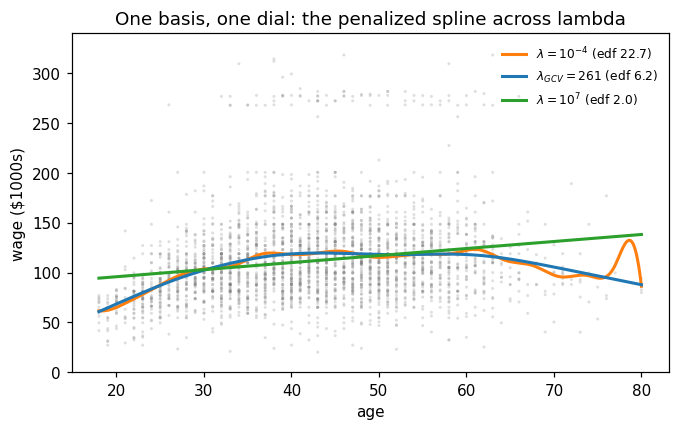

In [9]:
xg = np.linspace(xa.min(), xa.max(), 400)
Bg, _ = bspline_design(xg, xa.min(), xa.max(), nseg=20)
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(xa, yw, s=4, alpha=0.25, color='grey', edgecolor='none')
for lam, col, lab in [(1e-4, 'C1', r'$\lambda=10^{-4}$ (edf 22.7)'),
                      (lams[best], 'C0', rf'$\lambda_{{GCV}}={lams[best]:.0f}$ (edf {edfs[best]:.1f})'),
                      (1e7, 'C2', r'$\lambda=10^{7}$ (edf 2.0)')]:
    beta, _, _ = pspline_fit(lam)
    ax.plot(xg, Bg @ beta, color=col, lw=2, label=lab)
ax.set(xlabel='age', ylabel='wage ($1000s)', ylim=(0, 340),
       title='One basis, one dial: the penalized spline across lambda')
ax.legend(frameon=False, fontsize=8)
plt.show()

**Reading the output.** At $\lambda = 10^{-4}$ the fit burns $22.7$ edf and chases noise around age 78; at $\lambda = 10^7$ it collapses to a straight line ($2.0$ edf — the penalty's null space) and misses the plateau. GCV picks $\lambda = 261$, $\text{edf} = 6.2$ — close to the df Chapter 7 found by CV for this very curve. Report edf, not $\lambda$: $\lambda$'s scale depends on the basis, edf reads directly as "a curve worth $6.2$ parameters".

## 7. A penalized-spline GAM for Bikeshare

The meeting point: $\log\mu_i = \beta_0 + f_1(\texttt{hr}_i) + f_2(\texttt{temp}_i) + \beta_w\,\texttt{workingday}_i + \gamma^\top\texttt{weather}_i$ — a Poisson GLM whose two smooth terms are penalized B-splines, each with its own penalty weight chosen by `select_penweight` (a GCV-type criterion).

In [10]:
from statsmodels.gam.api import GLMGam, BSplines

xs = bike[['hr', 'temp']].astype(float)
bs = BSplines(xs, df=[12, 6], degree=[3, 3])     # rich bases for hr, temp
Xpar = pd.DataFrame({                            # the parametric part
    'const': 1.0,
    'workingday': bike.workingday.astype(float),
    'w_cloudy': (bike.weathersit == 'cloudy/misty').astype(float),
    'w_light':  (bike.weathersit == 'light rain/snow').astype(float),
    'w_heavy':  (bike.weathersit == 'heavy rain/snow').astype(float),
})

gam = GLMGam(bike.bikers, exog=Xpar, smoother=bs,
             family=sm.families.Poisson(), alpha=[1.0, 1.0])
_ = gam.fit()                                    # initial fit (sets the model scale)
alpha_hat = gam.select_penweight()[0]            # GCV-type choice, ~15s
print('selected penalty weights (hr, temp):', np.round(alpha_hat, 3))

gam = GLMGam(bike.bikers, exog=Xpar, smoother=bs,
             family=sm.families.Poisson(), alpha=list(alpha_hat))
res = gam.fit()
npar = Xpar.shape[1]
print(f'deviance {res.deviance:.0f}   AIC {res.aic:.0f}   '
      f'(GLM with dummy hr + linear temp: {pois.deviance:.0f} / {pois.aic:.0f})')
print(f'edf: hour smooth {res.edf[npar:npar+11].sum():.1f},  temp smooth {res.edf[npar+11:].sum():.1f}')
print(f'weather (light rain) coefficient: {res.params["w_light"]:.3f}   (GLM: {pois.params["C(weathersit)[T.light rain/snow]"]:.3f})')

selected penalty weights (hr, temp): [0.319 0.004]
deviance 259650   AIC 312730   (GLM with dummy hr + linear temp: 269006 / 322102)
edf: hour smooth 11.0,  temp smooth 5.0
weather (light rain) coefficient: -0.569   (GLM: -0.505)


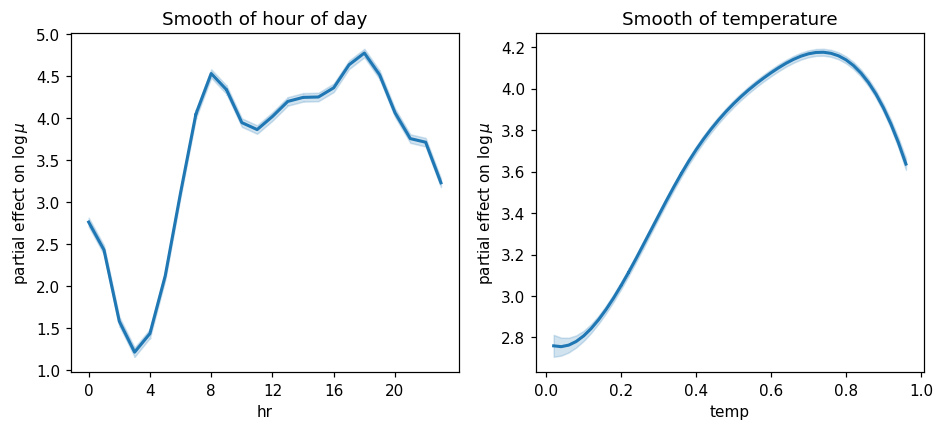

f(18) = 4.77,  f(3) = 1.21  ->  6 p.m. vs 3 a.m. rate ratio e^3.56 = 35x
smooth 17:00 vs 04:00: 24.6x   (the dummy-hr GLM said 55.4x)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for k, ax, var, ttl in [(0, axes[0], 'hr', 'Smooth of hour of day'),
                        (1, axes[1], 'temp', 'Smooth of temperature')]:
    vals, se = res.partial_values(k)
    xv = bike[var].values.astype(float)
    o = np.argsort(xv)
    ax.fill_between(xv[o], (vals - 2*se)[o], (vals + 2*se)[o], alpha=0.2, color='C0')
    ax.plot(xv[o], vals[o], color='C0', lw=2)
    ax.set(xlabel=var, ylabel=r'partial effect on $\log\mu$', title=ttl)
axes[0].set_xticks(range(0, 24, 4))
plt.show()

hrv = bike['hr'].values
vals, _ = res.partial_values(0)
f18, f3 = vals[hrv == 18][0], vals[hrv == 3][0]
print(f'f(18) = {f18:.2f},  f(3) = {f3:.2f}  ->  6 p.m. vs 3 a.m. rate ratio e^{f18-f3:.2f} = {np.exp(f18-f3):.0f}x')
f17, f4 = vals[hrv == 17][0], vals[hrv == 4][0]
print(f'smooth 17:00 vs 04:00: {np.exp(f17-f4):.1f}x   (the dummy-hr GLM said 55.4x)')

**Reading the output.** The machine chose light penalties — with $8{,}645$ observations the data can afford $\approx 11$ edf for the hour curve and $\approx 5$ for temperature — and the smooth-temp model beats the linear-temp GLM by $\sim 9{,}400$ AIC points with *fewer* effective parameters: the linear-temp assumption was the binding constraint. The hour curve troughs at 3 a.m. and peaks at the two commutes ($e^{4.77-1.21} \approx 35\times$); the temperature curve *falls* above temp $\approx 0.75$ ($\sim 31^\circ$C) — the hot-weather dip a linear term is structurally unable to show. One honest caveat: smooths smooth — the dummy model rates 17:00 at $55.4\times$ the 04:00 level, the penalized curve says $24.6\times$; for genuinely discontinuous patterns, factors beat a heavily penalized smooth.

## Lecture exercises — worked Python solutions

These are the **[Python]-tagged exercises from the lecture slides**, solved step by step; run them cell by cell and compare with the slide solutions. Data loads through the `load()` helper defined in the Setup cell, so every cell works locally and on Colab.

### Exercise A4.3 — Rate ratios on Bikeshare [Python]

**Task (from the slides).** Using the fitted Poisson GLM (`bikers ~ C(hr) + temp + workingday + C(weathersit)`):
1. compute the rate ratio for `light rain/snow` versus `clear`, and phrase it as a percentage change in expected riders;
2. the `temp` coefficient is $\hat\beta = 1.567$ — by what factor does the expected count change when `temp` rises by $0.2$ (about $8^\circ$C)? Write the one line of Python that computes it from `pois.params`;
3. why would it be wrong to say "a $0.2$ rise in temp *adds* $0.2 \times 1.567 = 0.31$ bikers"?

In [12]:
# (1) --------------------------------------------------------------------
b_light = pois.params['C(weathersit)[T.light rain/snow]']
print(f'beta = {b_light:.3f}   rate ratio e^beta = {np.exp(b_light):.3f}'
      f'   ->  {1 - np.exp(b_light):.1%} fewer expected riders than clear weather')

# (2) --------------------------------------------------------------------
print(round(float(np.exp(0.2 * pois.params['temp'])), 3))   # Expected: 1.368

beta = -0.505   rate ratio e^beta = 0.603   ->  39.7% fewer expected riders than clear weather
1.368


**(3) Interpretation.** $0.31$ is a change in $\log\mu$, not in $\mu$. The additive reading confuses the two scales: the actual change in expected riders depends on the starting level — $+36.8\%$ of $10$ riders is $\approx 3.7$ riders, of $400$ riders $\approx 147$. On the log link, $\hat\beta_j$ is a **log rate ratio**; only $e^{\hat\beta_j}$ has a direct count-scale meaning.

### Extended Exercise A4.2 — Build and defend a count GAM [Python]

**Task (from the slides).** Using `GLMGam` with `BSplines(df=[12, 6], degree=[3, 3])` on `hr` and `temp`, plus parametric `workingday` and weather dummies:
1. write down the model equation for $\log\mu_i$ and say which parts are penalized;
2. the selected penalties give edf $\approx 11$ (hr) and $\approx 5$ (temp) — what would edf $\approx 2$ for `temp` have told you?
3. from the fitted hour smooth, $f(18) = 4.77$ and $f(3) = 1.21$: compute the 6 p.m. vs 3 a.m. rate ratio;
4. the GAM's weather coefficient is $-0.569$ (light rain) vs the GLM's $-0.505$ — give one reason the estimates differ;
5. name the single most important robustness check before this model ships.

In [13]:
# (2)-(4): every number, recomputed from the Section 7 fit -----------------
print(f'edf hour {res.edf[npar:npar+11].sum():.1f},  edf temp {res.edf[npar+11:].sum():.1f}')
print(f'f(18) = {f18:.2f}, f(3) = {f3:.2f}  ->  rate ratio e^{f18-f3:.2f} = {np.exp(f18-f3):.0f}x')
print(f'GAM light rain {res.params["w_light"]:.3f}   vs GLM {pois.params["C(weathersit)[T.light rain/snow]"]:.3f}')

# (5): the overdispersion audit applies to GAMs verbatim -------------------
mu_hat = res.fittedvalues
phi_gam = np.sum((bike.bikers - mu_hat)**2 / mu_hat) / (len(bike) - res.edf.sum())
print(f'GAM Pearson dispersion: {phi_gam:.1f}  (still >> 1 — widen the uncertainty!)')

edf hour 11.0,  edf temp 5.0
f(18) = 4.77, f(3) = 1.21  ->  rate ratio e^3.56 = 35x
GAM light rain -0.569   vs GLM -0.505
GAM Pearson dispersion: 30.7  (still >> 1 — widen the uncertainty!)


**Reading the output.**
1. $\log\mu_i = \beta_0 + f_1(\texttt{hr}_i) + f_2(\texttt{temp}_i) + \beta_w\,\texttt{workingday}_i + \gamma_1\texttt{cloudy}_i + \gamma_2\texttt{light}_i + \gamma_3\texttt{heavy}_i$ — only $f_1$ and $f_2$ are penalized (each with its own $\alpha$); the intercept, dummies and $\beta_w$ are ordinary ML parameters.
2. edf $\approx 2$ for `temp` would mean the penalty had shrunk the smooth to near-linearity — the data see no curvature, and the linear-temp GLM would have been adequate. The actual edf $\approx 5$ says the bend (including the hot-weather dip) is real structure.
3. $e^{4.77 - 1.21} = e^{3.56} \approx 35$: holding temperature, weather and day type fixed, 6 p.m. carries about $35\times$ the 3 a.m. count.
4. The two models adjust for temperature differently — the GLM forces a linear temp effect, the GAM lets it bend. Rainy hours are also cool hours, so when the temperature adjustment changes shape, the weather dummies absorb a different share of the rain–cold overlap. Coefficients of correlated regressors always move when a co-regressor's functional form changes.
5. The **overdispersion audit** of the GAM itself: its Pearson dispersion is still $\gg 1$, so shipping the $35\times$ headline with Poisson bands would overstate certainty roughly $5$–$6$-fold. Flexible means do not repair broken variances — quasi rescaling or an NB-GAM before anything ships.

## 8. Exercises

1. Add an `hr × workingday` interaction to the Poisson GLM of Section 3 and re-test `workingday`. Does the heterogeneity story of Section 5 (positive at commutes, negative at night) show up in the coefficients?
2. Refit Section 5's negative binomial with `alpha` fixed at half and at double the ML estimate. How sensitive are the coefficients and their SEs?
3. In Section 6, replace GCV with 10-fold cross-validation on the $\lambda$ grid. Does the chosen edf change materially?
4. Fit the Section 7 GAM with `df=[24, 6]` for the hour basis. Does more basis freedom bring the 17:00-vs-04:00 ratio closer to the dummy model's $55.4\times$, and what happens to the edf?